In [116]:
import os
import pandas as pd
import numpy as np
import csv
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import pearsonr
from scipy.stats import norm
import seaborn as sns
import pybaseball as bb
import datetime
from pybaseball import statcast
from pybaseball import statcast_batter
from pybaseball import statcast_pitcher_percentile_ranks
from pybaseball import statcast_pitcher_spin_dir_comp
from pybaseball import statcast_pitcher_arsenal_stats
from pybaseball import playerid_reverse_lookup
import requests
import json
from typing import Dict, Any, Optional, List, Union
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed


In [117]:
statcast_2025 = statcast("2025-03-27", "2025-09-28")

This is a large query, it may take a moment to complete


/Users/gmarrero/Desktop/Personal_Projects/.venv/lib/python3.12/site-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
  0%|          | 0/186 [00:00<?, ?it/s]/Users/gmarrero/Desktop/Personal_Projects/.venv/lib/python3.12/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `err

In [118]:
statcast_2025

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2013,FF,2025-09-28,95.7,-2.15,5.21,"Weissert, Greg",678009,669711,field_out,hit_into_play,...,2,1.56,0.71,-0.71,20.9,5.991833,-1.319512,28.782516,41.559201,30.599805
2059,FF,2025-09-28,95.1,-1.91,5.1,"Weissert, Greg",668670,669711,strikeout,called_strike,...,9,1.59,0.93,0.93,20.5,<NA>,<NA>,<NA>,<NA>,<NA>
2150,FF,2025-09-28,95.4,-1.99,5.22,"Weissert, Greg",668670,669711,NaN,foul,...,9,1.36,0.85,0.85,22.9,2.871131,31.805044,22.266527,37.478847,15.582717
2235,SL,2025-09-28,84.8,-2.33,4.72,"Weissert, Greg",668670,669711,NaN,swinging_strike,...,9,2.55,-0.32,-0.32,12.3,13.78541,4.08139,32.414181,38.011685,27.083341
2366,SL,2025-09-28,85.3,-2.26,4.85,"Weissert, Greg",668670,669711,NaN,called_strike,...,9,2.71,-0.52,-0.52,15.8,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723,FF,2025-03-27,94.4,-2.88,5.77,"King, Michael",663586,650633,NaN,ball,...,1,1.08,0.72,0.72,38.3,<NA>,<NA>,<NA>,<NA>,<NA>
3874,FF,2025-03-27,94.3,-3.02,5.71,"King, Michael",663586,650633,NaN,swinging_strike,...,1,1.1,1.05,1.05,33.4,2.776964,6.214351,50.389859,35.670775,21.975569
3979,CH,2025-03-27,87.3,-3.25,5.4,"King, Michael",595777,650633,single,hit_into_play,...,1,2.47,1.93,-1.93,25.3,10.611278,-5.009623,33.59613,37.256978,32.942551
4128,SI,2025-03-27,92.3,-3.27,5.45,"King, Michael",595777,650633,NaN,ball,...,1,2.59,1.64,-1.64,26.1,<NA>,<NA>,<NA>,<NA>,<NA>


In [119]:
qualified_batter_data = statcast_2025[statcast_2025['release_speed'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['player_name'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['batter'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['pitcher'].notna()]

In [120]:
qualified_batter_data.columns.tolist()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [121]:
events_only = qualified_batter_data[qualified_batter_data['events'].notna()]
events_only

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2013,FF,2025-09-28,95.7,-2.15,5.21,"Weissert, Greg",678009,669711,field_out,hit_into_play,...,2,1.56,0.71,-0.71,20.9,5.991833,-1.319512,28.782516,41.559201,30.599805
2059,FF,2025-09-28,95.1,-1.91,5.1,"Weissert, Greg",668670,669711,strikeout,called_strike,...,9,1.59,0.93,0.93,20.5,<NA>,<NA>,<NA>,<NA>,<NA>
2458,SI,2025-09-28,95.2,-2.38,4.77,"Weissert, Greg",628451,669711,single,hit_into_play,...,9,2.25,1.47,1.47,12.2,3.499958,4.504044,28.666057,43.129212,23.469592
3224,FF,2025-09-28,94.4,-2.08,5.1,"Weissert, Greg",700242,669711,walk,ball,...,<NA>,1.49,0.85,-0.85,20.1,<NA>,<NA>,<NA>,<NA>,<NA>
4145,ST,2025-09-28,80.8,-3.05,3.94,"Weissert, Greg",595879,669711,strikeout,swinging_strike,...,2,2.89,-1.73,-1.73,-3.2,20.446141,-37.645879,23.644508,60.178614,51.5125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,CH,2025-03-27,88.4,-3.24,5.43,"King, Michael",645277,650633,force_out,hit_into_play,...,1,2.51,1.85,-1.85,21.6,10.181477,11.897774,30.32874,48.04773,30.159864
2350,SL,2025-03-27,85.0,-3.01,5.55,"King, Michael",542303,650633,walk,ball,...,1,3.44,-0.35,-0.35,26.3,<NA>,<NA>,<NA>,<NA>,<NA>
2898,SI,2025-03-27,93.7,-3.28,5.36,"King, Michael",621566,650633,walk,ball,...,1,2.05,2.2,-2.2,24.4,<NA>,<NA>,<NA>,<NA>,<NA>
3439,CH,2025-03-27,88.9,-3.13,5.44,"King, Michael",663586,650633,field_out,hit_into_play,...,1,2.1,1.95,1.95,22.5,18.361032,-2.703176,40.4623,38.760703,37.480645


In [122]:
# Events that do NOT count as an official at-bat
non_ab_events = {
    'walk', 'intent_walk', 'hit_by_pitch',
    'sac_bunt', 'sac_fly', 'sac_bunt_double_play', 'sac_fly_double_play',
    'catcher_interf', 'truncated_pa'
}

# Only rows where a plate appearance actually ended (events is non-null)
pa_ending = events_only[events_only['events'].notna()].copy()

# Mark which of those PA-ending events count as an at-bat
pa_ending['is_ab'] = ~pa_ending['events'].isin(non_ab_events)

# Sum ABs per batter
ab_counts = pa_ending.groupby('batter')['is_ab'].sum()

# Batters with 100+ ABs in the window
qualified_batter_ids = ab_counts[ab_counts >= 100].index

# Filter the full pitch-level data down to those batters
qualified_batter_data = statcast_2025[statcast_2025['batter'].isin(qualified_batter_ids)].copy()

In [123]:
qualified_batter_data

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2013,FF,2025-09-28,95.7,-2.15,5.21,"Weissert, Greg",678009,669711,field_out,hit_into_play,...,2,1.56,0.71,-0.71,20.9,5.991833,-1.319512,28.782516,41.559201,30.599805
2059,FF,2025-09-28,95.1,-1.91,5.1,"Weissert, Greg",668670,669711,strikeout,called_strike,...,9,1.59,0.93,0.93,20.5,<NA>,<NA>,<NA>,<NA>,<NA>
2150,FF,2025-09-28,95.4,-1.99,5.22,"Weissert, Greg",668670,669711,NaN,foul,...,9,1.36,0.85,0.85,22.9,2.871131,31.805044,22.266527,37.478847,15.582717
2235,SL,2025-09-28,84.8,-2.33,4.72,"Weissert, Greg",668670,669711,NaN,swinging_strike,...,9,2.55,-0.32,-0.32,12.3,13.78541,4.08139,32.414181,38.011685,27.083341
2366,SL,2025-09-28,85.3,-2.26,4.85,"Weissert, Greg",668670,669711,NaN,called_strike,...,9,2.71,-0.52,-0.52,15.8,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723,FF,2025-03-27,94.4,-2.88,5.77,"King, Michael",663586,650633,NaN,ball,...,1,1.08,0.72,0.72,38.3,<NA>,<NA>,<NA>,<NA>,<NA>
3874,FF,2025-03-27,94.3,-3.02,5.71,"King, Michael",663586,650633,NaN,swinging_strike,...,1,1.1,1.05,1.05,33.4,2.776964,6.214351,50.389859,35.670775,21.975569
3979,CH,2025-03-27,87.3,-3.25,5.4,"King, Michael",595777,650633,single,hit_into_play,...,1,2.47,1.93,-1.93,25.3,10.611278,-5.009623,33.59613,37.256978,32.942551
4128,SI,2025-03-27,92.3,-3.27,5.45,"King, Michael",595777,650633,NaN,ball,...,1,2.59,1.64,-1.64,26.1,<NA>,<NA>,<NA>,<NA>,<NA>


In [124]:
qualified_batter_ids

Index([455117, 456781, 457705, 457759, 467793, 500743, 502054, 502671, 514888,
       516782,
       ...
       805300, 805367, 805373, 805779, 807712, 807713, 807799, 808975, 808982,
       810938],
      dtype='Int64', name='batter', length=442)

In [125]:
rhb = qualified_batter_data[qualified_batter_data["stand"] == "R"]
lhp = qualified_batter_data[qualified_batter_data["stand"] == "L"]

rhp = qualified_batter_data[qualified_batter_data["p_throws"] == "R"]
lhp = qualified_batter_data[qualified_batter_data["p_throws"] == "L"]

rhp_rhb = rhp[rhp["stand"] == "R"]
rhp_lhb = rhp[rhp["stand"] == "L"]

lhp_rhb = lhp[lhp["stand"] == "R"]
lhp_lhb = lhp[lhp["stand"] == "L"]

In [126]:
arm_angle_stats = rhp['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats['range'] = arm_angle_stats['max'] - arm_angle_stats['min']
print("Arm Angle Summary Statistics (vs_rhp):")
print(arm_angle_stats)

Arm Angle Summary Statistics (vs_rhp):
count    487515.000000
min         -67.400000
max          87.100000
mean         37.486087
std          12.675135
range       154.500000
Name: arm_angle, dtype: float64


In [127]:
arm_angle_stats = lhp['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats['range'] = arm_angle_stats['max'] - arm_angle_stats['min']
print("Arm Angle Summary Statistics (vs_lhp):")
print(arm_angle_stats)

Arm Angle Summary Statistics (vs_lhp):
count    180320.000000
min         -32.700000
max          78.700000
mean         38.135570
std          13.372609
range       111.400000
Name: arm_angle, dtype: float64


/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/2109134116.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lhp['arm_angle_bin'] = pd.cut(lhp['arm_angle'], bins=arm_angle_bins_custom, right=False)
/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/2109134116.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arm_angle_event_counts_lhp = lhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

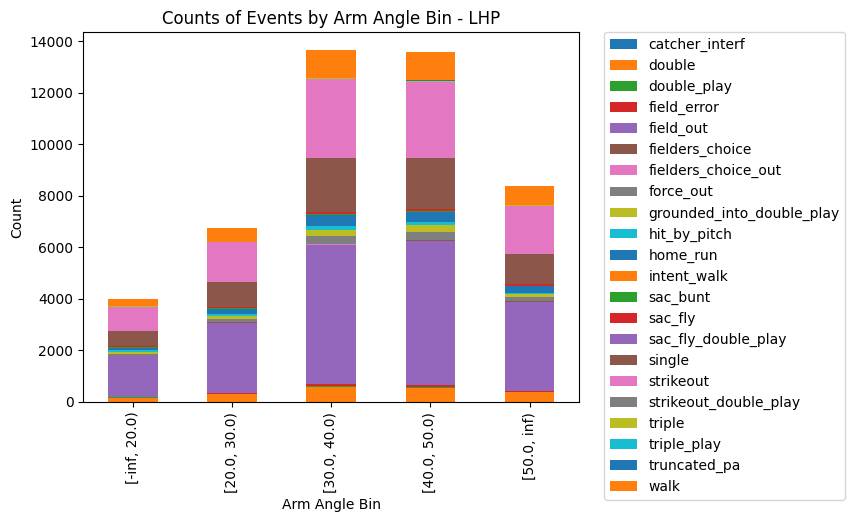

In [128]:
# Define the bins and labels for arm angle
arm_angle_bins_custom = [-float('inf'), 20, 30, 40, 50, float('inf')]

lhp['arm_angle_bin'] = pd.cut(lhp['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_lhp = lhp['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_lhp

# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_lhp = lhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_lhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_lhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - LHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/3260194738.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rhp['arm_angle_bin'] = pd.cut(rhp['arm_angle'], bins=arm_angle_bins_custom, right=False)
/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/3260194738.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arm_angle_event_counts_rhp = rhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

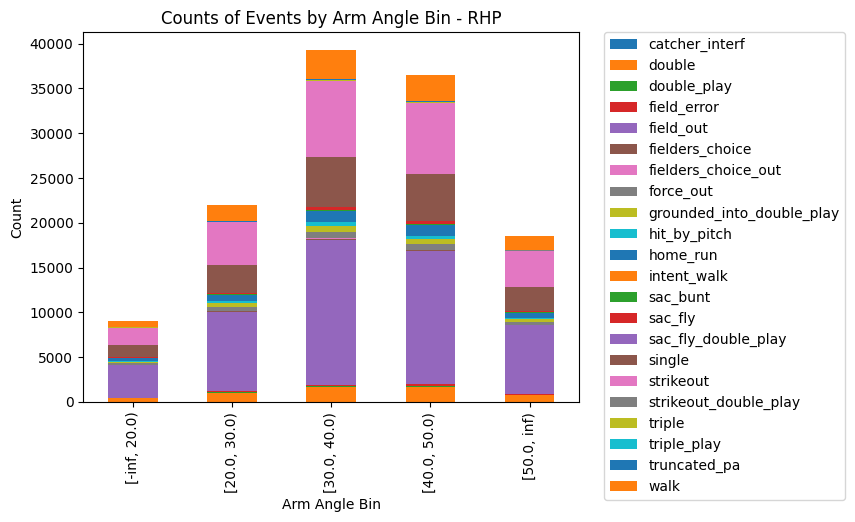

In [129]:
# Define the bins and labels for arm angle
arm_angle_bins_custom = [-float('inf'), 20, 30, 40, 50, float('inf')]

rhp['arm_angle_bin'] = pd.cut(rhp['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_rhp = rhp['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_rhp

# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_rhp = rhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_rhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_rhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - RHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

In [130]:
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(sorted(arm_angle_event_counts_lhp.columns), axis=1)
arm_angle_event_counts_lhp


events,catcher_interf,double,double_play,field_error,field_out,fielders_choice,fielders_choice_out,force_out,grounded_into_double_play,hit_by_pitch,...,sac_bunt,sac_fly,sac_fly_double_play,single,strikeout,strikeout_double_play,triple,triple_play,truncated_pa,walk
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,163,7,25,1571,6,10,82,62,68,...,21,26,0,589,945,1,20,0,10,287
"[20.0, 30.0)",5,289,16,46,2714,12,11,121,103,94,...,29,48,0,974,1537,4,19,0,7,511
"[30.0, 40.0)",4,585,23,66,5394,30,33,305,252,134,...,45,98,1,2078,3058,3,38,0,25,1075
"[40.0, 50.0)",2,544,22,87,5592,25,22,312,255,108,...,48,94,1,1956,2965,5,46,1,24,1070
"[50.0, inf)",1,367,12,44,3464,17,12,150,127,46,...,24,65,0,1175,1856,3,24,0,11,736


In [131]:
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(sorted(arm_angle_event_counts_rhp.columns), axis=1)
arm_angle_event_counts_rhp

events,catcher_interf,double,double_play,field_error,field_out,fielders_choice,fielders_choice_out,force_out,grounded_into_double_play,hit_by_pitch,...,sac_bunt,sac_fly,sac_fly_double_play,single,strikeout,strikeout_double_play,triple,triple_play,truncated_pa,walk
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",2,403,20,56,3634,22,21,157,160,127,...,32,71,0,1378,1914,9,43,0,16,735
"[20.0, 30.0)",11,1005,52,142,8880,53,35,420,389,272,...,56,133,3,3068,4785,20,73,0,38,1830
"[30.0, 40.0)",20,1625,87,181,16206,86,60,695,681,470,...,90,272,4,5632,8435,26,137,1,70,3289
"[40.0, 50.0)",23,1632,83,201,14947,69,54,586,612,364,...,84,262,3,5281,7912,30,140,0,64,2925
"[50.0, inf)",11,748,33,100,7664,40,36,317,300,126,...,51,148,1,2671,4063,14,63,0,30,1535


In [132]:
# Ensure all columns from qualified_batter_data['events'] are present in arm_angle_event_counts_lhp (add with 0s if missing)
all_events = qualified_batter_data['events'].unique()
# Ensure all columns from all_events are present in arm_angle_event_counts_lhp (add missing ones, fill with 0)
for event in all_events:
    if event not in arm_angle_event_counts_lhp.columns:
        arm_angle_event_counts_lhp[event] = 0
    if event not in arm_angle_event_counts_rhp.columns:
        arm_angle_event_counts_rhp[event] = 0
# Reorder columns to match all_events order
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_lhp

# Reorder columns to match all_events order
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_rhp

events,field_out,strikeout,NaN,single,walk,grounded_into_double_play,double,home_run,force_out,hit_by_pitch,...,field_error,sac_bunt,intent_walk,fielders_choice,double_play,strikeout_double_play,truncated_pa,catcher_interf,sac_fly_double_play,triple_play
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",3634,1914,0,1378,735,160,403,273,157,127,...,56,32,0,22,20,9,16,2,0,0
"[20.0, 30.0)",8880,4785,0,3068,1830,389,1005,731,420,272,...,142,56,0,53,52,20,38,11,3,0
"[30.0, 40.0)",16206,8435,0,5632,3289,681,1625,1250,695,470,...,181,90,0,86,87,26,70,20,4,1
"[40.0, 50.0)",14947,7912,0,5281,2925,612,1632,1230,586,364,...,201,84,0,69,83,30,64,23,3,0
"[50.0, inf)",7664,4063,0,2671,1535,300,748,587,317,126,...,100,51,0,40,33,14,30,11,1,0


In [133]:
arm_angle_event_counts_lhp['strikeout'] = arm_angle_event_counts_lhp['strikeout'] + arm_angle_event_counts_lhp['strikeout_double_play']
arm_angle_event_counts_lhp['field_out'] = arm_angle_event_counts_lhp['field_out'] + arm_angle_event_counts_lhp['fielders_choice']
arm_angle_event_counts_lhp['sac_fly'] = arm_angle_event_counts_lhp['sac_fly'] + arm_angle_event_counts_lhp['sac_fly_double_play']
arm_angle_event_counts_lhp['double_play'] = arm_angle_event_counts_lhp['double_play'] + arm_angle_event_counts_lhp['grounded_into_double_play']

arm_angle_event_counts_lhp.drop(columns=['truncated_pa', 'catcher_interf','fielders_choice', 'strikeout_double_play', 'grounded_into_double_play', 'sac_fly_double_play', np.nan], inplace=True)

arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(sorted(arm_angle_event_counts_lhp.columns), axis=1)

arm_angle_event_counts_lhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,intent_walk,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk
arm_angle_bin,,,,,,,,,,,,,,,,
"[-inf, 20.0)",163,69,25,1577,10,82,68,115,0,21,26,589,946,20,0,287
"[20.0, 30.0)",289,119,46,2726,11,121,94,197,0,29,48,974,1541,19,0,511
"[30.0, 40.0)",585,275,66,5424,33,305,134,421,0,45,99,2078,3061,38,0,1075
"[40.0, 50.0)",544,277,87,5617,22,312,108,390,0,48,95,1956,2970,46,1,1070
"[50.0, inf)",367,139,44,3481,12,150,46,252,0,24,65,1175,1859,24,0,736


In [134]:
arm_angle_event_counts_rhp['strikeout'] = arm_angle_event_counts_rhp['strikeout'] + arm_angle_event_counts_rhp['strikeout_double_play']
arm_angle_event_counts_rhp['field_out'] = arm_angle_event_counts_rhp['field_out'] + arm_angle_event_counts_rhp['fielders_choice']
arm_angle_event_counts_rhp['sac_fly'] = arm_angle_event_counts_rhp['sac_fly'] + arm_angle_event_counts_rhp['sac_fly_double_play']
arm_angle_event_counts_rhp['double_play'] = arm_angle_event_counts_rhp['double_play'] + arm_angle_event_counts_rhp['grounded_into_double_play']

arm_angle_event_counts_rhp.drop(columns=['truncated_pa', 'catcher_interf','fielders_choice', 'strikeout_double_play', 'grounded_into_double_play', 'sac_fly_double_play', np.nan], inplace=True)

arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(sorted(arm_angle_event_counts_rhp.columns), axis=1)

arm_angle_event_counts_rhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,intent_walk,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk
arm_angle_bin,,,,,,,,,,,,,,,,
"[-inf, 20.0)",403,180,56,3656,21,157,127,273,0,32,71,1378,1923,43,0,735
"[20.0, 30.0)",1005,441,142,8933,35,420,272,731,0,56,136,3068,4805,73,0,1830
"[30.0, 40.0)",1625,768,181,16292,60,695,470,1250,0,90,276,5632,8461,137,1,3289
"[40.0, 50.0)",1632,695,201,15016,54,586,364,1230,0,84,265,5281,7942,140,0,2925
"[50.0, inf)",748,333,100,7704,36,317,126,587,0,51,149,2671,4077,63,0,1535


In [135]:
# Create a copy so that we don't overwrite the original
lhp_stats = arm_angle_event_counts_lhp.copy()


# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

lhp_stats['hits'] = lhp_stats[hits_cols].sum(axis=1)


ab_events = [
    "double", "double_play", "field_error", "field_out",
    "fielders_choice_out", "force_out", "home_run",
    "single", "strikeout", "triple", "triple_play"
]

pa_events = [
    "double", "double_play", "field_error", "field_out",
    "fielders_choice_out", "force_out", "hit_by_pitch",
    "home_run", "intent_walk", "sac_bunt", "sac_fly",
    "single", "strikeout", "triple", "triple_play", "walk"
]

lhp_stats["AB"] = lhp_stats[ab_events].sum(axis=1)
lhp_stats["PA"] = lhp_stats[pa_events].sum(axis=1)

lhp_stats['Batting_Average'] = lhp_stats['hits'] / lhp_stats['AB']

lhp_stats['Slugging_Percentage'] = ((lhp_stats['home_run'] * 4) + (lhp_stats['double'] * 2) + (lhp_stats['triple'] * 3) + (lhp_stats['single'] * 1)) / (lhp_stats['AB'])

lhp_stats['On_Base_Percentage'] = (lhp_stats['hits'] + lhp_stats['walk'] + lhp_stats['hit_by_pitch'] + lhp_stats['intent_walk']) / (lhp_stats['AB'] + lhp_stats['intent_walk'] + lhp_stats['walk'] + lhp_stats['hit_by_pitch'] + lhp_stats['sac_fly'])

lhp_stats['On_Base_Plus_Slugging'] = lhp_stats['On_Base_Percentage'] + lhp_stats['Slugging_Percentage']


lhp_stats['K_Rate'] = ((lhp_stats['strikeout']) / (lhp_stats['PA']))

lhp_stats['BB_Rate'] = ((lhp_stats['walk'] + lhp_stats['hit_by_pitch']) / (lhp_stats['PA'] - lhp_stats['intent_walk']))

lhp_stats

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,intent_walk,sac_bunt,...,walk,hits,AB,PA,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",163,69,25,1577,10,82,68,115,0,21,...,287,887,3596,3998,0.246663,0.399055,0.312296,0.711350,0.236618,0.088794
"[20.0, 30.0)",289,119,46,2726,11,121,94,197,0,29,...,511,1479,6043,6725,0.244746,0.396657,0.311231,0.707888,0.229145,0.089963
"[30.0, 40.0)",585,275,66,5424,33,305,134,421,0,45,...,1075,3122,12286,13639,0.254110,0.410711,0.318596,0.729308,0.224430,0.088643
"[40.0, 50.0)",544,277,87,5617,22,312,108,390,0,48,...,1070,2936,12222,13543,0.240223,0.387989,0.304854,0.692843,0.219301,0.086982
"[50.0, inf)",367,139,44,3481,12,150,46,252,0,24,...,736,1818,7503,8374,0.242303,0.398374,0.311377,0.709751,0.221997,0.093384


In [136]:
# Create a copy so that we don't overwrite the original
rhp_stats = arm_angle_event_counts_rhp.copy()


# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

rhp_stats['hits'] = rhp_stats[hits_cols].sum(axis=1)


ab_events = [
    "double", "double_play", "field_error", "field_out",
    "fielders_choice_out", "force_out", "home_run",
    "single", "strikeout", "triple", "triple_play"
]

pa_events = [
    "double", "double_play", "field_error", "field_out",
    "fielders_choice_out", "force_out", "hit_by_pitch",
    "home_run", "intent_walk", "sac_bunt", "sac_fly",
    "single", "strikeout", "triple", "triple_play", "walk"
]

rhp_stats["AB"] = rhp_stats[ab_events].sum(axis=1)
rhp_stats["PA"] = rhp_stats[pa_events].sum(axis=1)

rhp_stats['Batting_Average'] = rhp_stats['hits'] / rhp_stats['AB']

rhp_stats['Slugging_Percentage'] = ((rhp_stats['home_run'] * 4) + (rhp_stats['double'] * 2) + (rhp_stats['triple'] * 3) + (rhp_stats['single'] * 1)) / (rhp_stats['AB'])

rhp_stats['On_Base_Percentage'] = (rhp_stats['hits'] + rhp_stats['walk'] + rhp_stats['hit_by_pitch'] + rhp_stats['intent_walk']) / (rhp_stats['AB'] + rhp_stats['intent_walk'] + rhp_stats['walk'] + rhp_stats['hit_by_pitch'] + rhp_stats['sac_fly'])

rhp_stats['On_Base_Plus_Slugging'] = rhp_stats['On_Base_Percentage'] + rhp_stats['Slugging_Percentage']


rhp_stats['K_Rate'] = ((rhp_stats['strikeout']) / (rhp_stats['PA']))

rhp_stats['BB_Rate'] = ((rhp_stats['walk'] + rhp_stats['hit_by_pitch']) / (rhp_stats['PA'] - rhp_stats['intent_walk']))

rhp_stats

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,intent_walk,sac_bunt,...,walk,hits,AB,PA,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",403,180,56,3656,21,157,127,273,0,32,...,735,2097,8090,9055,0.259209,0.420890,0.327940,0.748830,0.212369,0.095196
"[20.0, 30.0)",1005,441,142,8933,35,420,272,731,0,56,...,1830,4877,19653,21947,0.248155,0.418308,0.318807,0.737114,0.218937,0.095776
"[30.0, 40.0)",1625,768,181,16292,60,695,470,1250,0,90,...,3289,8644,35102,39227,0.246254,0.407185,0.316912,0.724097,0.215693,0.095827
"[40.0, 50.0)",1632,695,201,15016,54,586,364,1230,0,84,...,2925,8283,32777,36415,0.252708,0.423620,0.318516,0.742136,0.218097,0.090320
"[50.0, inf)",748,333,100,7704,36,317,126,587,0,51,...,1535,4069,16636,18497,0.244590,0.402981,0.310636,0.713618,0.220414,0.089798


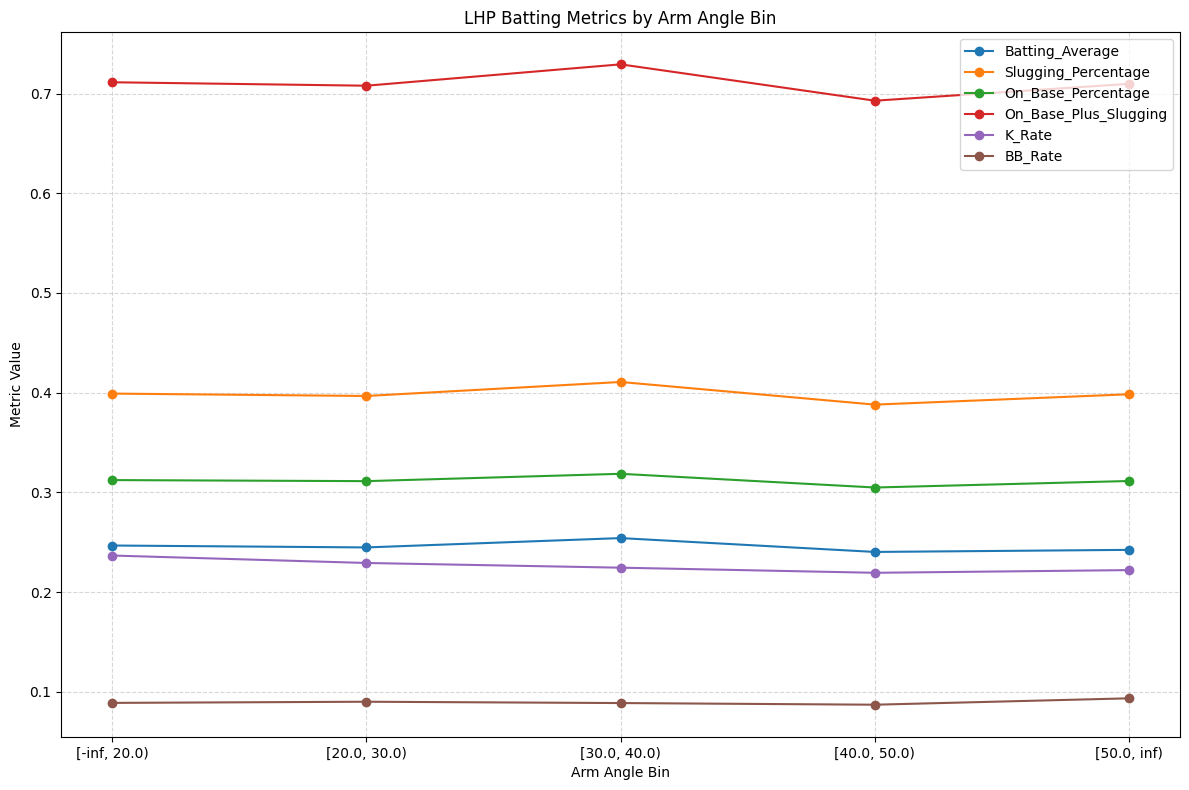

In [137]:
# Select the metrics to plot
metrics = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 
           'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']

# Get the bin labels from the index
bins = lhp_stats.index.astype(str)

plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(bins, lhp_stats[metric], marker='o', label=metric)

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('LHP Batting Metrics by Arm Angle Bin')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

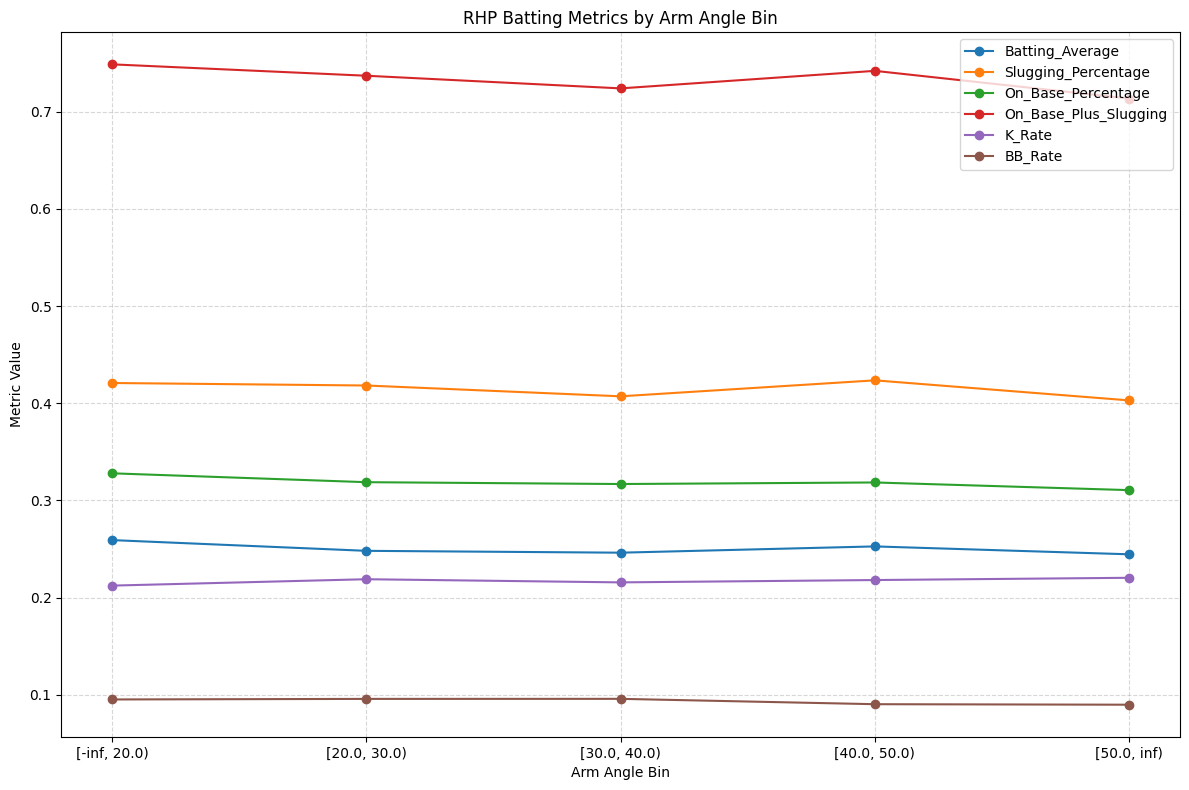

In [138]:
# Select the metrics to plot
metrics = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 
           'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']

# Get the bin labels from the index
bins = rhp_stats.index.astype(str)

plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(bins, rhp_stats[metric], marker='o', label=metric)

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('RHP Batting Metrics by Arm Angle Bin')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [139]:
# Build the same arm-angle-bin rate-stat pipeline used for lhp_stats/rhp_stats,
# reused here for the batter-handedness splits (lhp_rhb, lhp_lhb).
def build_arm_angle_rate_stats(df, bins=arm_angle_bins_custom, all_event_types=all_events):
    df = df.copy()
    df['arm_angle_bin'] = pd.cut(df['arm_angle'], bins=bins, right=False)

    counts = df.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)

    for event in all_event_types:
        if event not in counts.columns:
            counts[event] = 0
    counts = counts.reindex(columns=all_event_types, fill_value=0)

    counts['strikeout'] = counts['strikeout'] + counts['strikeout_double_play']
    counts['field_out'] = counts['field_out'] + counts['fielders_choice']
    counts['sac_fly'] = counts['sac_fly'] + counts['sac_fly_double_play']
    counts['double_play'] = counts['double_play'] + counts['grounded_into_double_play']
    counts = counts.drop(columns=['truncated_pa', 'catcher_interf', 'fielders_choice',
                                   'strikeout_double_play', 'grounded_into_double_play',
                                   'sac_fly_double_play', np.nan], errors='ignore')
    counts = counts.reindex(sorted(counts.columns), axis=1)

    stats = counts.copy()
    hits_cols = ['single', 'double', 'triple', 'home_run']
    stats['hits'] = stats[hits_cols].sum(axis=1)

    # NOTE: this matches the same at-bat-based denominator used in lhp_stats/rhp_stats above,
    # so these numbers stay directly comparable. (Flagging, not fixing here: this denominator
    # is technically an AB proxy, not true PA, which understates OBP's denominator.)
    ab_like = (stats['hits'] + stats['double_play'] + stats['field_error'] + stats['field_out']
               + stats['fielders_choice_out'] + stats['force_out'] + stats['strikeout'] + stats['triple_play'])

    stats['Batting_Average'] = stats['hits'] / ab_like
    stats['Slugging_Percentage'] = ((stats['home_run'] * 4) + (stats['double'] * 2)
                                     + (stats['triple'] * 3) + (stats['single'] * 1)) / ab_like
    stats['On_Base_Percentage'] = (stats['hits'] + stats['walk'] + stats['hit_by_pitch']) / ab_like
    stats['On_Base_Plus_Slugging'] = stats['On_Base_Percentage'] + stats['Slugging_Percentage']
    stats['K_Rate'] = stats['strikeout'] / (stats['field_out'] + stats['strikeout'] + stats['force_out']
                                             + stats['field_error'] + stats['fielders_choice_out'] + stats['hits'])
    stats['BB_Rate'] = (stats['walk'] + stats['hit_by_pitch']) / (stats['field_out'] + stats['strikeout']
                                             + stats['force_out'] + stats['field_error'] + stats['fielders_choice_out'] + stats['hits'])

    return stats

lhp_rhb_stats = build_arm_angle_rate_stats(lhp_rhb)
lhp_lhb_stats = build_arm_angle_rate_stats(lhp_lhb)

rhp_rhb_stats = build_arm_angle_rate_stats(rhp_rhb)
rhp_lhb_stats = build_arm_angle_rate_stats(rhp_lhb)

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/4195290858.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/4195290858.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/4195290858.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass ob

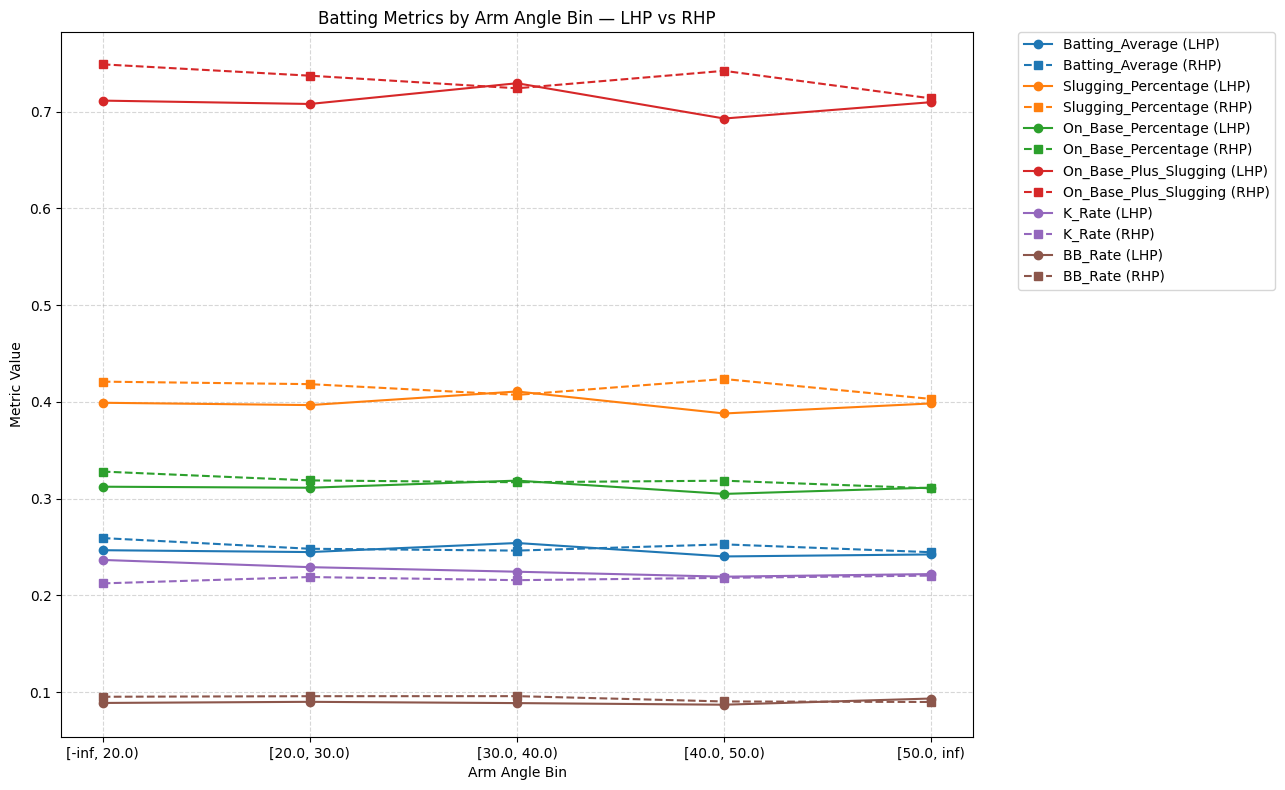

In [140]:
# Combined LHP vs RHP comparison: all 6 metrics, same color per metric,
# solid line = LHP, dashed line = RHP, so the key clearly separates metric from pitcher hand.
metrics = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage',
           'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']

colors = plt.cm.tab10.colors
bins = lhp_stats.index.astype(str)

plt.figure(figsize=(13, 8))
for i, metric in enumerate(metrics):
    plt.plot(bins, lhp_stats[metric], marker='o', linestyle='-', color=colors[i],
             label=f'{metric} (LHP)')
    plt.plot(bins, rhp_stats[metric], marker='s', linestyle='--', color=colors[i],
             label=f'{metric} (RHP)')

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('Batting Metrics by Arm Angle Bin — LHP vs RHP')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

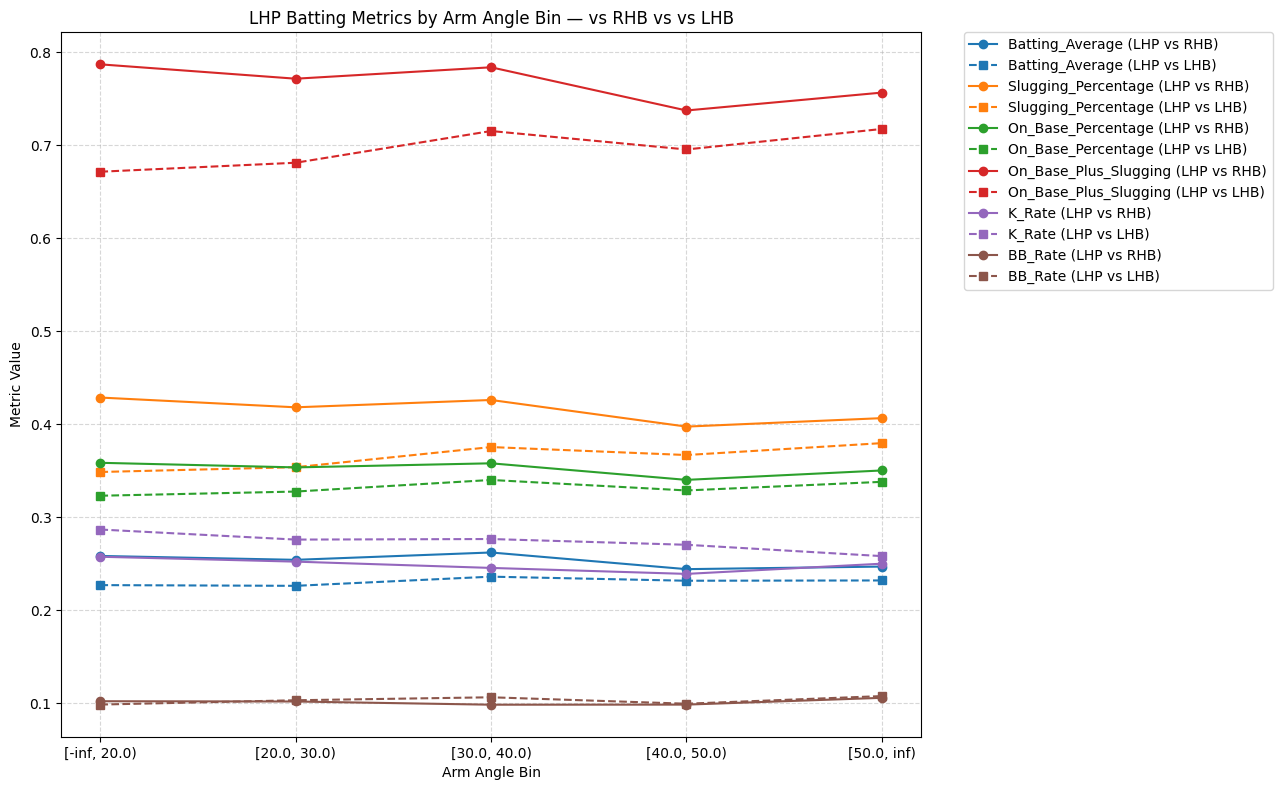

In [141]:
# Combined comparison for LHP specifically: vs RHB vs vs LHB.
# Same color-per-metric / solid-vs-dashed convention as the LHP-vs-RHP chart above.
bins = lhp_rhb_stats.index.astype(str)

plt.figure(figsize=(13, 8))
for i, metric in enumerate(metrics):
    plt.plot(bins, lhp_rhb_stats[metric], marker='o', linestyle='-', color=colors[i],
             label=f'{metric} (LHP vs RHB)')
    plt.plot(bins, lhp_lhb_stats[metric], marker='s', linestyle='--', color=colors[i],
             label=f'{metric} (LHP vs LHB)')

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('LHP Batting Metrics by Arm Angle Bin — vs RHB vs vs LHB')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

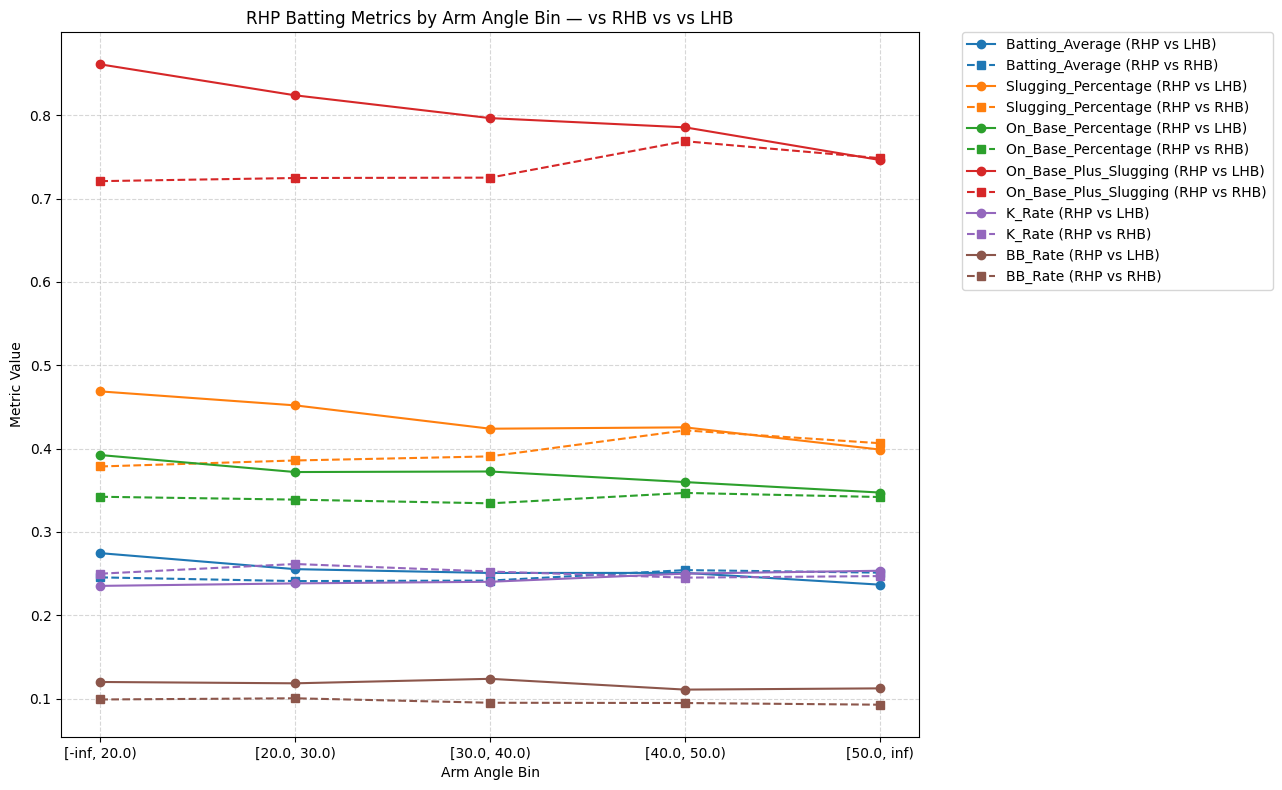

In [142]:
# Combined comparison for RHP specifically: vs RHB vs vs LHB.
# Same color-per-metric / solid-vs-dashed convention as the LHP-vs-RHP chart above.
bins = rhp_rhb_stats.index.astype(str)

plt.figure(figsize=(13, 8))
for i, metric in enumerate(metrics):
    plt.plot(bins, rhp_lhb_stats[metric], marker='o', linestyle='-', color=colors[i],
             label=f'{metric} (RHP vs LHB)')
    plt.plot(bins, rhp_rhb_stats[metric], marker='s', linestyle='--', color=colors[i],
             label=f'{metric} (RHP vs RHB)')

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('RHP Batting Metrics by Arm Angle Bin — vs RHB vs vs LHB')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [143]:
# Per-batter, per-arm-angle-bin outcome counts and rate stats.
# Pooled across LHP and RHP (arm angle bin is the grouping variable of interest here,
# not pitcher hand) -- same event-consolidation and denominator logic as lhp_stats/rhp_stats.
qualified_batter_data['arm_angle_bin'] = pd.cut(qualified_batter_data['arm_angle'], bins=arm_angle_bins_custom, right=False)

batter_bin_counts = qualified_batter_data.groupby(['batter', 'arm_angle_bin', 'events']).size().unstack(fill_value=0)

for event in all_events:
    if event not in batter_bin_counts.columns:
        batter_bin_counts[event] = 0
batter_bin_counts = batter_bin_counts.reindex(columns=all_events, fill_value=0)

batter_bin_counts['strikeout'] = batter_bin_counts['strikeout'] + batter_bin_counts['strikeout_double_play']
batter_bin_counts['field_out'] = batter_bin_counts['field_out'] + batter_bin_counts['fielders_choice']
batter_bin_counts['sac_fly'] = batter_bin_counts['sac_fly'] + batter_bin_counts['sac_fly_double_play']
batter_bin_counts['double_play'] = batter_bin_counts['double_play'] + batter_bin_counts['grounded_into_double_play']
batter_bin_counts = batter_bin_counts.drop(columns=['truncated_pa', 'catcher_interf', 'fielders_choice',
                                                      'strikeout_double_play', 'grounded_into_double_play',
                                                      'sac_fly_double_play', np.nan], errors='ignore')
batter_bin_counts = batter_bin_counts.reindex(sorted(batter_bin_counts.columns), axis=1)

batter_bin_stats = batter_bin_counts.copy()
hits_cols = ['single', 'double', 'triple', 'home_run']
batter_bin_stats['hits'] = batter_bin_stats[hits_cols].sum(axis=1)

# Same AB-like denominator used throughout the rest of the notebook, for consistency
batter_bin_stats['AB'] = (batter_bin_stats['hits'] + batter_bin_stats['double_play'] + batter_bin_stats['field_error']
                           + batter_bin_stats['field_out'] + batter_bin_stats['fielders_choice_out']
                           + batter_bin_stats['force_out'] + batter_bin_stats['strikeout'] + batter_bin_stats['triple_play'])

batter_bin_stats['Batting_Average'] = batter_bin_stats['hits'] / batter_bin_stats['AB']
batter_bin_stats['Slugging_Percentage'] = ((batter_bin_stats['home_run'] * 4) + (batter_bin_stats['double'] * 2)
                                            + (batter_bin_stats['triple'] * 3) + (batter_bin_stats['single'] * 1)) / batter_bin_stats['AB']
batter_bin_stats['On_Base_Percentage'] = (batter_bin_stats['hits'] + batter_bin_stats['walk'] + batter_bin_stats['hit_by_pitch']) / batter_bin_stats['AB']
batter_bin_stats['On_Base_Plus_Slugging'] = batter_bin_stats['On_Base_Percentage'] + batter_bin_stats['Slugging_Percentage']

batter_bin_stats['K_BB_N'] = (batter_bin_stats['field_out'] + batter_bin_stats['strikeout'] + batter_bin_stats['force_out']
                               + batter_bin_stats['field_error'] + batter_bin_stats['fielders_choice_out'] + batter_bin_stats['hits'])
batter_bin_stats['K_Rate'] = batter_bin_stats['strikeout'] / batter_bin_stats['K_BB_N']
batter_bin_stats['BB_Rate'] = (batter_bin_stats['walk'] + batter_bin_stats['hit_by_pitch']) / batter_bin_stats['K_BB_N']
batter_bin_stats['PA'] = batter_bin_stats['AB'] + batter_bin_stats['walk'] + batter_bin_stats['hit_by_pitch']

batter_bin_stats = batter_bin_stats.reset_index()
batter_bin_stats

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/429427213.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batter_bin_counts = qualified_batter_data.groupby(['batter', 'arm_angle_bin', 'events']).size().unstack(fill_value=0)


events,batter,arm_angle_bin,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,...,hits,AB,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_BB_N,K_Rate,BB_Rate,PA
0,455117,"[-inf, 20.0)",0,0,0,3,0,0,0,2,...,2,6,0.333333,1.333333,0.500000,1.833333,6,0.166667,0.166667,7
1,455117,"[20.0, 30.0)",2,0,0,8,1,0,0,0,...,3,21,0.142857,0.238095,0.190476,0.428571,21,0.428571,0.047619,22
2,455117,"[30.0, 40.0)",2,2,0,18,1,0,0,1,...,9,49,0.183673,0.285714,0.204082,0.489796,47,0.404255,0.021277,50
3,455117,"[40.0, 50.0)",1,1,1,21,0,1,0,1,...,11,55,0.200000,0.272727,0.272727,0.545455,54,0.370370,0.074074,59
4,455117,"[50.0, inf)",1,0,0,3,0,0,0,0,...,5,16,0.312500,0.375000,0.375000,0.750000,16,0.500000,0.062500,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,810938,"[-inf, 20.0)",1,0,1,8,0,0,0,0,...,6,20,0.300000,0.350000,0.300000,0.650000,20,0.250000,0.000000,20
2206,810938,"[20.0, 30.0)",1,1,0,17,0,2,0,0,...,7,41,0.170732,0.195122,0.195122,0.390244,40,0.350000,0.025000,42
2207,810938,"[30.0, 40.0)",4,1,0,43,0,2,0,1,...,25,84,0.297619,0.380952,0.345238,0.726190,83,0.156627,0.048193,88
2208,810938,"[40.0, 50.0)",4,3,0,37,1,3,1,0,...,20,86,0.232558,0.279070,0.337209,0.616279,83,0.265060,0.108434,95


In [144]:
# League-wide rate stats per arm-angle bin (pooled across all pitchers), used as
# the baseline every batter gets compared against. Reuses the helper function from
# the LHP-vs-RHP comparison above.
league_bin_stats = build_arm_angle_rate_stats(qualified_batter_data)
league_bin_stats[['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage',
                   'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']]

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_7837/4195290858.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


events,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,
"[-inf, 20.0)",0.255348,0.414171,0.359490,0.773661,0.250852,0.106409
"[20.0, 30.0)",0.247354,0.413216,0.352701,0.765917,0.252467,0.107694
"[30.0, 40.0)",0.248291,0.408099,0.353127,0.761226,0.248619,0.107198
"[40.0, 50.0)",0.249317,0.413943,0.348586,0.762528,0.247854,0.101463
"[50.0, inf)",0.243879,0.401549,0.345085,0.746634,0.250813,0.103224


In [145]:
# Test each batter's rate stats against the league rate for that same arm-angle bin.
# AVG, OBP, K_Rate, and BB_Rate are true proportions, so a one-sample z-test against the
# league rate is appropriate. SLG and OPS are averages of a discrete 0-4 value, not simple
# proportions, so they don't get a formal p-value here -- just reported as a gap vs. league,
# flagged clearly as descriptive only.

league_lookup = league_bin_stats[['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage',
                                   'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']].add_prefix('league_')

results = batter_bin_stats.merge(league_lookup, left_on='arm_angle_bin', right_index=True, how='left')

def z_test_prop(p_hat, p0, n):
    with np.errstate(invalid='ignore', divide='ignore'):
        se = np.sqrt(p0 * (1 - p0) / n)
        z = (p_hat - p0) / se
        p_val = 2 * (1 - norm.cdf(np.abs(z)))
    return z, p_val

for stat, n_col in [('Batting_Average', 'AB'), ('On_Base_Percentage', 'AB'),
                     ('K_Rate', 'K_BB_N'), ('BB_Rate', 'K_BB_N')]:
    z, p = z_test_prop(results[stat], results[f'league_{stat}'], results[n_col])
    results[f'{stat}_z'] = z
    results[f'{stat}_p'] = p
    results[f'{stat}_significant'] = results[f'{stat}_p'] < 0.05

# Descriptive-only gap for SLG / OPS -- no p-value, sample size (AB) still reported alongside
results['Slugging_Percentage_vs_league'] = results['Slugging_Percentage'] - results['league_Slugging_Percentage']
results['On_Base_Plus_Slugging_vs_league'] = results['On_Base_Plus_Slugging'] - results['league_On_Base_Plus_Slugging']

results

events,batter,arm_angle_bin,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,...,On_Base_Percentage_p,On_Base_Percentage_significant,K_Rate_z,K_Rate_p,K_Rate_significant,BB_Rate_z,BB_Rate_p,BB_Rate_significant,Slugging_Percentage_vs_league,On_Base_Plus_Slugging_vs_league
0,455117,"[-inf, 20.0)",0,0,0,3,0,0,0,2,...,0.473214,False,-0.475688,0.634297,False,0.478662,0.632179,False,0.919163,1.059673
1,455117,"[20.0, 30.0)",2,0,0,8,1,0,0,0,...,0.119741,False,1.857649,0.063219,False,-0.888078,0.374499,False,-0.175121,-0.337345
2,455117,"[30.0, 40.0)",2,2,0,18,1,0,0,1,...,0.029040,True,2.468667,0.013562,True,-1.904059,0.056902,False,-0.122385,-0.271431
3,455117,"[40.0, 50.0)",1,1,1,21,0,1,0,1,...,0.237764,False,2.085181,0.037053,True,-0.666572,0.505046,False,-0.141215,-0.217074
4,455117,"[50.0, inf)",1,0,0,3,0,0,0,0,...,0.801266,False,2.299399,0.021482,True,-0.535399,0.592374,False,-0.026549,0.003366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,810938,"[-inf, 20.0)",1,0,1,8,0,0,0,0,...,0.579280,False,-0.008795,0.992983,False,-1.543245,0.122771,False,-0.064171,-0.123661
2206,810938,"[20.0, 30.0)",1,1,0,17,0,2,0,0,...,0.034711,True,1.419928,0.155629,False,-1.687143,0.091576,False,-0.218094,-0.375673
2207,810938,"[30.0, 40.0)",4,1,0,43,0,2,0,1,...,0.879749,False,-1.939074,0.052492,False,-1.737643,0.082274,False,-0.027147,-0.035036
2208,810938,"[40.0, 50.0)",4,3,0,37,1,3,1,0,...,0.824786,False,0.363068,0.716554,False,0.210334,0.833407,False,-0.134873,-0.146249


In [146]:
# Attach batter names, then pull a ranked leaderboard for a given bin/stat.
# Every row still carries its sample size (AB or K_BB_N) so you can eyeball how much
# to trust any individual result -- small samples were kept in, not filtered out.

unique_batter_ids = results['batter'].dropna().unique()
id_map = playerid_reverse_lookup(unique_batter_ids, key_type='mlbam')
id_map['batter_name'] = id_map['name_first'].str.title() + ' ' + id_map['name_last'].str.title()

results = results.merge(id_map[['key_mlbam', 'batter_name']], left_on='batter', right_on='key_mlbam', how='left')

def batters_vs_league(df, bin_label, stat='Batting_Average', direction='better', n_show=15, significant_only=True):
    n_col = 'AB' if stat in ('Batting_Average', 'On_Base_Percentage') else 'K_BB_N'
    subset = df[df['arm_angle_bin'] == bin_label].copy()
    if significant_only:
        subset = subset[subset[f'{stat}_significant'] == True]
    ascending = (direction == 'worse')
    cols = ['batter_name', 'arm_angle_bin', stat, f'league_{stat}', f'{stat}_z', f'{stat}_p', n_col]
    return subset.sort_values(f'{stat}_z', ascending=ascending)[cols].head(n_show)

# Example: batters with a significantly better-than-league AVG against arm angles < 20 degrees
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[0]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
670,Zach Mckinstry,"[-inf, 20.0)",0.514286,0.255348,3.513062,0.000443,35
1915,Tyler Soderstrom,"[-inf, 20.0)",0.478261,0.255348,3.467133,0.000526,46
1240,Austin Hays,"[-inf, 20.0)",0.500000,0.255348,3.173805,0.001505,32
1210,Xavier Edwards,"[-inf, 20.0)",0.454545,0.255348,3.030166,0.002444,44
1910,Colt Keith,"[-inf, 20.0)",0.459459,0.255348,2.847243,0.004410,37
1015,Gavin Lux,"[-inf, 20.0)",0.451613,0.255348,2.505993,0.012211,31
2045,Thomas Saggese,"[-inf, 20.0)",0.500000,0.255348,2.244219,0.024818,16
1595,Ryan Jeffers,"[-inf, 20.0)",0.440000,0.255348,2.117290,0.034235,25
445,Andy Ibáñez,"[-inf, 20.0)",0.500000,0.255348,2.099274,0.035793,14
855,Jake Mangum,"[-inf, 20.0)",0.419355,0.255348,2.094108,0.036250,31


In [147]:
# Example: batters with a significantly better-than-league AVG against arm angles < 20 degrees
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[0]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
670,Zach Mckinstry,"[-inf, 20.0)",0.514286,0.255348,3.513062,0.000443,35
1915,Tyler Soderstrom,"[-inf, 20.0)",0.478261,0.255348,3.467133,0.000526,46
1240,Austin Hays,"[-inf, 20.0)",0.500000,0.255348,3.173805,0.001505,32
1210,Xavier Edwards,"[-inf, 20.0)",0.454545,0.255348,3.030166,0.002444,44
1910,Colt Keith,"[-inf, 20.0)",0.459459,0.255348,2.847243,0.004410,37
1015,Gavin Lux,"[-inf, 20.0)",0.451613,0.255348,2.505993,0.012211,31
2045,Thomas Saggese,"[-inf, 20.0)",0.500000,0.255348,2.244219,0.024818,16
1595,Ryan Jeffers,"[-inf, 20.0)",0.440000,0.255348,2.117290,0.034235,25
445,Andy Ibáñez,"[-inf, 20.0)",0.500000,0.255348,2.099274,0.035793,14
855,Jake Mangum,"[-inf, 20.0)",0.419355,0.255348,2.094108,0.036250,31


In [148]:
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[1]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
236,Jurickson Profar,"[20.0, 30.0)",0.419355,0.247354,3.138865,0.001696,62
986,Jonathan Aranda,"[20.0, 30.0)",0.406250,0.247354,2.946112,0.003218,64
316,Trea Turner,"[20.0, 30.0)",0.358491,0.247354,2.651896,0.008004,106
2061,Colson Montgomery,"[20.0, 30.0)",0.432432,0.247354,2.609172,0.009076,37
856,Jake Mangum,"[20.0, 30.0)",0.367816,0.247354,2.604093,0.009212,87
1716,Elly De La Cruz,"[20.0, 30.0)",0.364706,0.247354,2.507530,0.012158,85
1786,Dominic Canzone,"[20.0, 30.0)",0.404255,0.247354,2.492997,0.012667,47
951,Juan Soto,"[20.0, 30.0)",0.358696,0.247354,2.475131,0.013319,92
1776,Sal Frelick,"[20.0, 30.0)",0.356322,0.247354,2.355617,0.018492,87
31,Tommy Pham,"[20.0, 30.0)",0.391304,0.247354,2.262757,0.023651,46


In [149]:
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[2]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
1612,Brendan Donovan,"[30.0, 40.0)",0.403361,0.248291,3.915596,0.000090,119
1042,Bo Bichette,"[30.0, 40.0)",0.357542,0.248291,3.383355,0.000716,179
987,Jonathan Aranda,"[30.0, 40.0)",0.375000,0.248291,3.318244,0.000906,128
202,Aaron Judge,"[30.0, 40.0)",0.354651,0.248291,3.228786,0.001243,172
57,Freddie Freeman,"[30.0, 40.0)",0.339181,0.248291,2.751134,0.005939,171
412,Pete Alonso,"[30.0, 40.0)",0.331606,0.248291,2.679164,0.007381,193
2072,Daylen Lile,"[30.0, 40.0)",0.367816,0.248291,2.580564,0.009864,87
2177,Jacob Wilson,"[30.0, 40.0)",0.324675,0.248291,2.194124,0.028227,154
342,Corey Seager,"[30.0, 40.0)",0.328467,0.248291,2.172210,0.029840,137
1517,Bobby Witt,"[30.0, 40.0)",0.313725,0.248291,2.163309,0.030517,204


In [150]:
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[3]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
1288,Yordan Álvarez,"[40.0, 50.0)",0.512821,0.249317,3.803779,0.000143,39
1718,Elly De La Cruz,"[40.0, 50.0)",0.329787,0.249317,2.550422,0.010759,188
1658,Andy Pages,"[40.0, 50.0)",0.335366,0.249317,2.547210,0.010859,164
2003,Nick Gonzales,"[40.0, 50.0)",0.351351,0.249317,2.484880,0.012960,111
1308,Iván Herrera,"[40.0, 50.0)",0.351852,0.249317,2.463093,0.013774,108
2153,Chandler Simpson,"[40.0, 50.0)",0.348214,0.249317,2.419306,0.015550,112
2178,Jacob Wilson,"[40.0, 50.0)",0.335714,0.249317,2.362990,0.018128,140
203,Aaron Judge,"[40.0, 50.0)",0.331034,0.249317,2.274557,0.022933,145
318,Trea Turner,"[40.0, 50.0)",0.316062,0.249317,2.143368,0.032084,193
1753,Brett Baty,"[40.0, 50.0)",0.336283,0.249317,2.136916,0.032605,113


In [151]:
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[4]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='better')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
1664,Heriberto Hernandez,"[50.0, inf)",0.421053,0.243879,2.543358,0.010979,38
1149,Brandon Marsh,"[50.0, inf)",0.383333,0.243879,2.515498,0.011886,60
39,Paul Goldschmidt,"[50.0, inf)",0.361446,0.243879,2.494250,0.012622,83
1334,Lawrence Butler,"[50.0, inf)",0.377049,0.243879,2.422079,0.015432,61
104,George Springer,"[50.0, inf)",0.358974,0.243879,2.367126,0.017927,78
1159,Shea Langeliers,"[50.0, inf)",0.369231,0.243879,2.353442,0.018601,65
2039,Wyatt Langford,"[50.0, inf)",0.354430,0.243879,2.288200,0.022126,79
544,Thairo Estrada,"[50.0, inf)",0.440000,0.243879,2.283551,0.022398,25
634,Yandy Díaz,"[50.0, inf)",0.348837,0.243879,2.266636,0.023412,86
1189,Will Smith,"[50.0, inf)",0.368421,0.243879,2.189625,0.028551,57


In [152]:
example_bin = sorted(results['arm_angle_bin'].dropna().unique())[4]
batters_vs_league(results, example_bin, stat='Batting_Average', direction='worse')

,batter_name,arm_angle_bin,Batting_Average,league_Batting_Average,Batting_Average_z,Batting_Average_p,AB
644,Yohel Pozo,"[50.0, inf)",0.062500,0.243879,-2.389348,0.016878,32
409,Anthony Santander,"[50.0, inf)",0.040000,0.243879,-2.373887,0.017602,25
1259,Luke Raley,"[50.0, inf)",0.040000,0.243879,-2.373887,0.017602,25
1679,Noelvi Marte,"[50.0, inf)",0.118644,0.243879,-2.240109,0.025084,59
1544,Jhonkensy Noel,"[50.0, inf)",0.068966,0.243879,-2.193511,0.028271,29
1059,Bo Naylor,"[50.0, inf)",0.108696,0.243879,-2.135108,0.032752,46
84,Marcell Ozuna,"[50.0, inf)",0.134328,0.243879,-2.088191,0.036781,67
1669,David Fry,"[50.0, inf)",0.050000,0.243879,-2.019125,0.043474,20
489,Ryan Mcmahon,"[50.0, inf)",0.144737,0.243879,-2.012719,0.044144,76
1719,Elly De La Cruz,"[50.0, inf)",0.158416,0.243879,-2.000127,0.045487,101
